<a href="https://colab.research.google.com/github/Rojoniaina-Rasoafarihy/Evo2_project/blob/main/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, confusion_matrix, f1_score)
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
import umap.umap_ as umap

In [ ]:
# Load embeddings and labels
LABEL_FILE = "gs://rojo_project/isolation_source_labels.csv"

In [ ]:
!mkdir -p /home/jupyter/data

In [ ]:
!gsutil -m cp -r gs://rojo_project/evo2_embeddings26_npz /home/jupyter/data/
!gsutil -m cp -r gs://rojo_project/evo2_embeddings_npz /home/jupyter/data/
!gsutil -m cp -r gs://rojo_project/evo2_embeddings32_npz /home/jupyter/data/

Streaming output truncated to the last 5000 lines.
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442515.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442435.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442555.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442675.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442715.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442595.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442575.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442695.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442635.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442795.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442495.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442615.1.npz...
Copying gs://rojo_project/evo2_embeddings32_npz/GCA_055442655.1.npz...
Copying gs://rojo_project/

In [ ]:
!ls /home/jupyter/data

evo2_embeddings26_npz  evo2_embeddings32_npz  evo2_embeddings_npz


In [ ]:
LABEL_FILE = "gs://rojo_project/isolation_source_labels.csv"
EMBEDDING_DIRS = {
    'block30': "/home/jupyter/data/evo2_embeddings32_npz",
    'block26': "/home/jupyter/data/evo2_embeddings26_npz",
    'block28': "/home/jupyter/data/evo2_embeddings_npz"
}

In [ ]:
# Load labels
label_df = pd.read_csv(LABEL_FILE)
label_dict = dict(zip(label_df["Assembly"], label_df["isolation source"]))

# Clinical mapping (
clinical_mapping = {
    'Bloodstream': 'Bloodstream',
    'Respiratory': 'Respiratory',
    'CF_Respiratory': 'Respiratory',
    'Urinary': 'Urinary',
    'Gastrointestinal': 'Gastrointestinal',
    'Wound': 'Wound_Skin',
    'Skin_Soft_Tissue': 'Wound_Skin',
    'Medical_Device': 'Medical_Device',
    'Hospital': 'Medical_Device',
    'Air': 'Environmental',
    'Water': 'Environmental',
    'Soil': 'Environmental',
    'Crop': 'Environmental',
    'Domestic': 'Environmental',
    'Industrial': 'Environmental',
    'Marine': 'Environmental',
    'Lab_Strain': 'Environmental',
    'Ocular': 'Other_Clinical',
    'Reproductive': 'Other_Clinical',
    'Bone_Joint': 'Other_Clinical',
    'Ear_Nose_Throat': 'Other_Clinical',
    'Bird': 'Other_Clinical',
    'Experimental': 'Other_Clinical',
}

In [ ]:
def load_embeddings(embedding_dir, label_dict, clinical_mapping, min_samples=5):
    """Load embeddings and apply filtering"""
    X_list = []
    y_list = []
    stems = []

    embedding_path = Path(embedding_dir)
    for npz_path in embedding_path.glob("*.npz"):
        stem = npz_path.stem
        if stem not in label_dict:
            continue
        data = np.load(npz_path)
        X_list.append(data["embedding"])
        y_list.append(label_dict[stem])
        stems.append(stem)

    X = np.array(X_list)
    y = np.array(y_list)

    # Apply clinical mapping
    y_mapped = [clinical_mapping.get(label, 'Environmental') for label in y]

    # Filter classes with minimum samples
    class_counts = Counter(y_mapped)
    keep_classes = [cls for cls, cnt in class_counts.items() if cnt >= min_samples]

    mask = [label in keep_classes for label in y_mapped]
    X_filtered = X[mask]
    y_filtered = [y_mapped[i] for i in range(len(mask)) if mask[i]]
    genome_names_filtered = [stems[i] for i in range(len(mask)) if mask[i]]

    # Encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y_filtered)

    return X_filtered, y_enc, le.classes_, genome_names_filtered

In [ ]:
def plot_pca_comparison(embeddings_dict, class_names_dict, y_enc_dict):
    """Plot PCA for different layers side by side"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (layer_name, X_data) in enumerate(embeddings_dict.items()):
        # Perform PCA
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_data)
        y_enc = y_enc_dict[layer_name]
        classes = class_names_dict[layer_name]

        # Plot
        ax = axes[idx]
        for i, cls in enumerate(classes):
            mask = y_enc == i
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      s=20, alpha=0.6, label=cls)

        ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
        ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
        ax.set_title(f"PCA - {layer_name}")
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.savefig("pca_comparison_layers.png", dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
def evaluate_classifier(X, y, classifier_name, classifier, n_splits=5):
    """Cross-validation evaluation for a classifier"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    fold_accuracies = []
    fold_f1_macro = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train classifier
        clf = classifier
        clf.fit(X_train_scaled, y_train)

        # Predictions
        y_pred = clf.predict(X_test_scaled)
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(X_test_scaled)
        else:
            y_proba = None

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        fold_accuracies.append(acc)
        fold_f1_macro.append(f1_macro)

        # Store
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        if y_proba is not None:
            all_y_proba.append(y_proba)

    # Combine results
    if all_y_proba:
        all_y_proba = np.vstack(all_y_proba)
        auc_macro = roc_auc_score(all_y_true, all_y_proba, multi_class='ovr', average='macro')
    else:
        auc_macro = None

    return {
        'accuracy_mean': np.mean(fold_accuracies),
        'accuracy_std': np.std(fold_accuracies),
        'f1_macro_mean': np.mean(fold_f1_macro),
        'f1_macro_std': np.std(fold_f1_macro),
        'auc_macro': auc_macro,
        'y_true': all_y_true,
        'y_pred': all_y_pred,
        'classification_report': classification_report(all_y_true, all_y_pred)
    }

In [ ]:
embeddings_data = {}
for layer_name, dir_path in EMBEDDING_DIRS.items():
    print(f"\nLoading {layer_name}...")
    X, y, classes, genomes = load_embeddings(dir_path, label_dict, clinical_mapping)
    embeddings_data[layer_name] = {
        'X': X,
        'y': y,
        'classes': classes,
        'genomes': genomes
    }
    print(f"  Samples: {X.shape[0]}, Features: {X.shape[1]}")
    print(f"  Classes: {list(classes)}")


Loading block30...
  Samples: 29920, Features: 8192
  Classes: [np.str_('Bloodstream'), np.str_('Environmental'), np.str_('Gastrointestinal'), np.str_('Medical_Device'), np.str_('Other_Clinical'), np.str_('Respiratory'), np.str_('Urinary'), np.str_('Wound_Skin')]

Loading block26...
  Samples: 29920, Features: 8192
  Classes: [np.str_('Bloodstream'), np.str_('Environmental'), np.str_('Gastrointestinal'), np.str_('Medical_Device'), np.str_('Other_Clinical'), np.str_('Respiratory'), np.str_('Urinary'), np.str_('Wound_Skin')]

Loading block28...
  Samples: 29920, Features: 8192
  Classes: [np.str_('Bloodstream'), np.str_('Environmental'), np.str_('Gastrointestinal'), np.str_('Medical_Device'), np.str_('Other_Clinical'), np.str_('Respiratory'), np.str_('Urinary'), np.str_('Wound_Skin')]


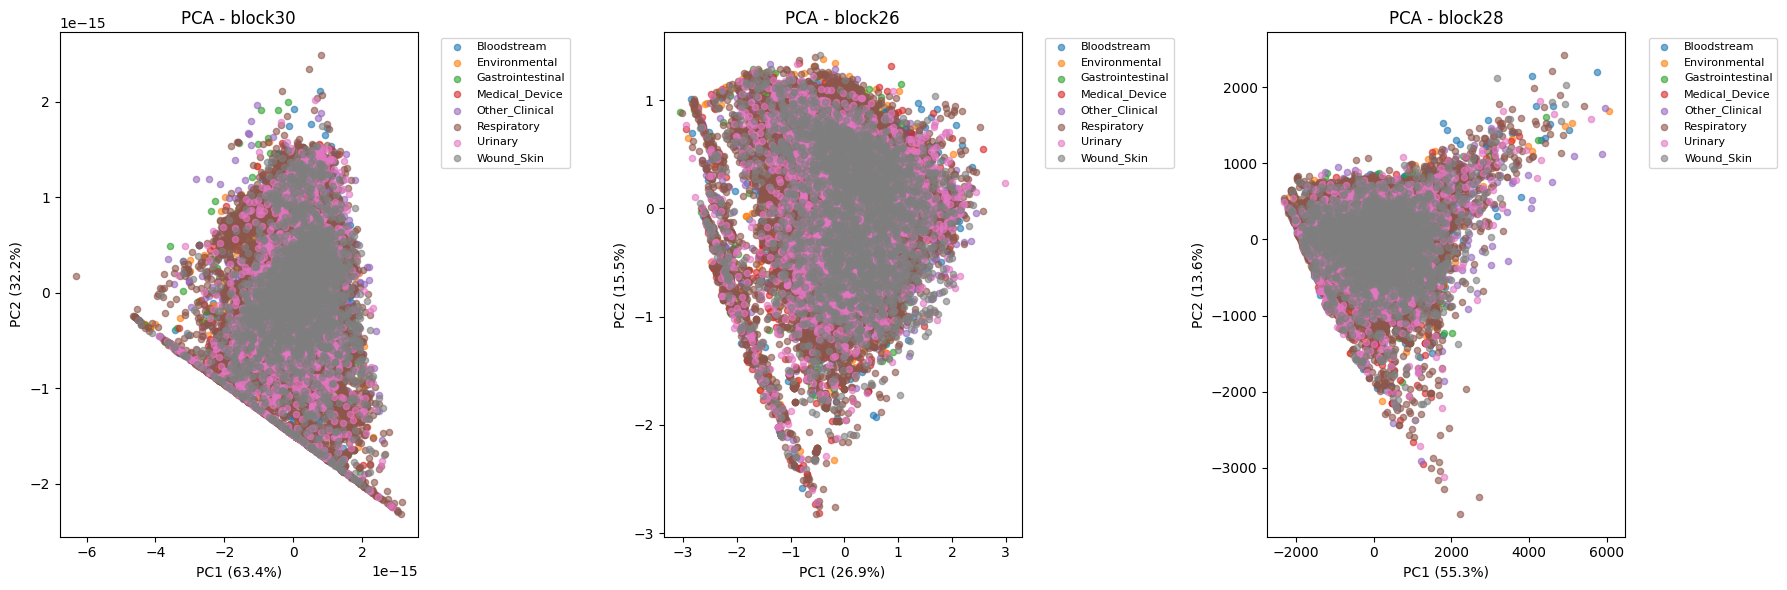

In [ ]:
# Prepare dictionaries for PCA function
X_dict = {layer: data['X'] for layer, data in embeddings_data.items()}
y_dict = {layer: data['y'] for layer, data in embeddings_data.items()}
classes_dict = {layer: data['classes'] for layer, data in embeddings_data.items()}

plot_pca_comparison(X_dict, classes_dict, y_dict)

In [ ]:
# Define classifiers to test
classifiers = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        multi_class='ovr'
    )
}

# Store results
results = {}

In [ ]:
for layer_name, data in embeddings_data.items():
    print(f"\n{'='*50}")
    print(f"LAYER: {layer_name.upper()}")
    print(f"{'='*50}")

    X = data['X']
    y = data['y']
    classes = data['classes']

    results[layer_name] = {}

    for clf_name, clf in classifiers.items():
        print(f"\n--- {clf_name} ---")

        # Evaluate
        eval_results = evaluate_classifier(X, y, clf_name, clf)
        results[layer_name][clf_name] = eval_results

        # Print results
        print(f"Accuracy: {eval_results['accuracy_mean']:.4f} (+/- {eval_results['accuracy_std']:.4f})")
        print(f"F1-macro: {eval_results['f1_macro_mean']:.4f} (+/- {eval_results['f1_macro_std']:.4f})")
        if eval_results['auc_macro']:
            print(f"ROC-AUC (macro): {eval_results['auc_macro']:.4f}")
        print("\nClassification Report:")
        print(eval_results['classification_report'])


LAYER: BLOCK30

--- Random Forest ---
Accuracy: 0.5367 (+/- 0.0059)
F1-macro: 0.3027 (+/- 0.0045)
ROC-AUC (macro): 0.7508

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.10      0.16      2430
           1       0.52      0.26      0.35      1767
           2       0.34      0.23      0.27      1315
           3       0.36      0.28      0.31      1741
           4       0.40      0.21      0.28      1137
           5       0.60      0.87      0.71     15558
           6       0.28      0.16      0.21      3383
           7       0.24      0.09      0.13      2589

    accuracy                           0.54     29920
   macro avg       0.39      0.28      0.30     29920
weighted avg       0.47      0.54      0.48     29920


--- Logistic Regression ---
Accuracy: 0.3069 (+/- 0.0070)
F1-macro: 0.2253 (+/- 0.0052)
ROC-AUC (macro): 0.6683

Classification Report:
              precision    recall  f1-score   support

          

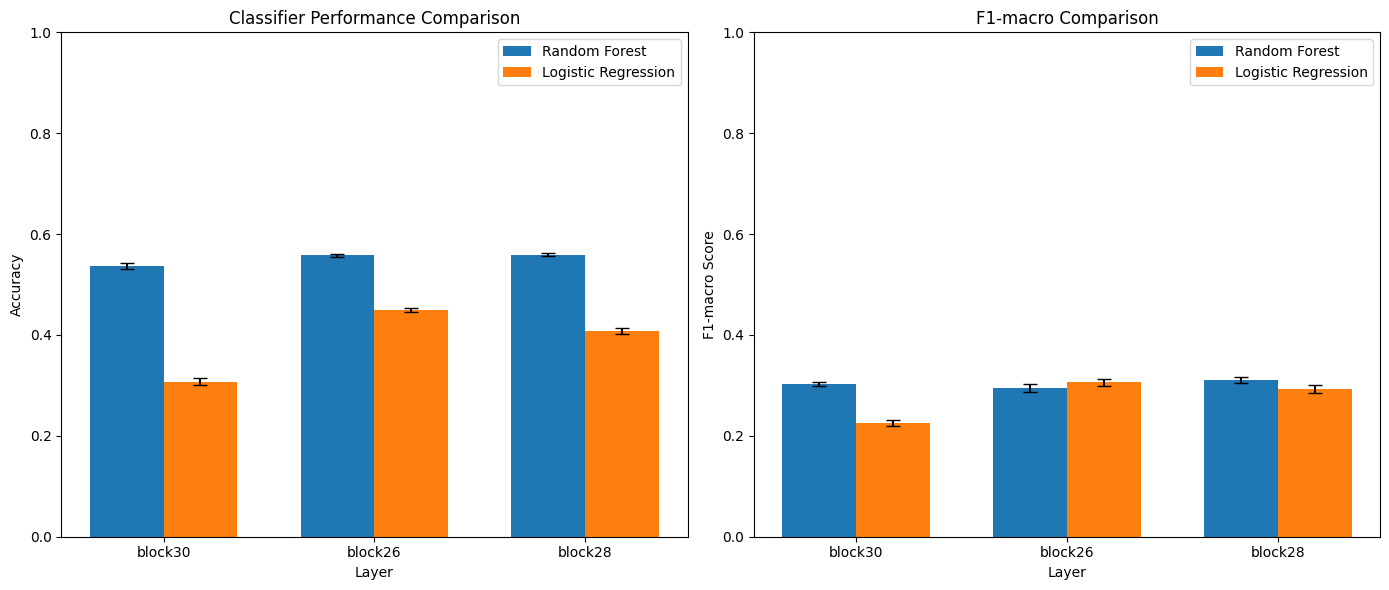

In [ ]:
# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy comparison
ax1 = axes[0]
layers = list(results.keys())
x_pos = np.arange(len(layers))
width = 0.35

for i, clf_name in enumerate(classifiers.keys()):
    accuracies = [results[layer][clf_name]['accuracy_mean'] for layer in layers]
    errors = [results[layer][clf_name]['accuracy_std'] for layer in layers]
    ax1.bar(x_pos + i*width, accuracies, width, label=clf_name, yerr=errors, capsize=5)

ax1.set_xlabel('Layer')
ax1.set_ylabel('Accuracy')
ax1.set_title('Classifier Performance Comparison')
ax1.set_xticks(x_pos + width/2)
ax1.set_xticklabels(layers)
ax1.legend()
ax1.set_ylim([0, 1])

# Plot 2: F1-macro comparison
ax2 = axes[1]
for i, clf_name in enumerate(classifiers.keys()):
    f1_scores = [results[layer][clf_name]['f1_macro_mean'] for layer in layers]
    errors = [results[layer][clf_name]['f1_macro_std'] for layer in layers]
    ax2.bar(x_pos + i*width, f1_scores, width, label=clf_name, yerr=errors, capsize=5)

ax2.set_xlabel('Layer')
ax2.set_ylabel('F1-macro Score')
ax2.set_title('F1-macro Comparison')
ax2.set_xticks(x_pos + width/2)
ax2.set_xticklabels(layers)
ax2.legend()
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("classifier_layer_comparison.png", dpi=200)
plt.show()


Best Configuration: block28 + Random Forest (Accuracy: 0.5592)


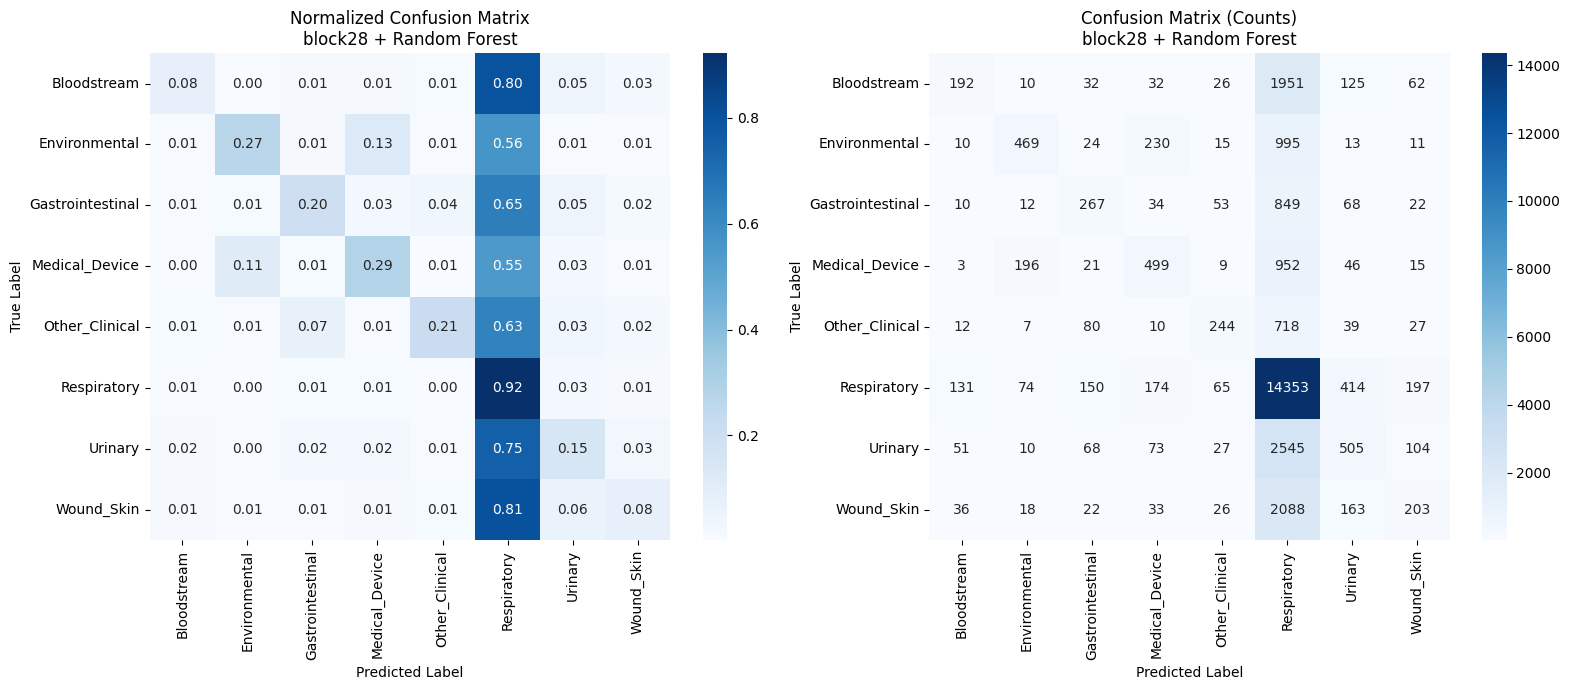

In [ ]:
# Find best performing configuration
best_accuracy = 0
best_config = None

for layer_name in results:
    for clf_name in results[layer_name]:
        acc = results[layer_name][clf_name]['accuracy_mean']
        if acc > best_accuracy:
            best_accuracy = acc
            best_config = (layer_name, clf_name)

print(f"\nBest Configuration: {best_config[0]} + {best_config[1]} (Accuracy: {best_accuracy:.4f})")

# Plot confusion matrix for best configuration
best_results = results[best_config[0]][best_config[1]]
cm = confusion_matrix(best_results['y_true'], best_results['y_pred'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Normalized confusion matrix
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=embeddings_data[best_config[0]]['classes'],
            yticklabels=embeddings_data[best_config[0]]['classes'],
            ax=axes[0])
axes[0].set_title(f'Normalized Confusion Matrix\n{best_config[0]} + {best_config[1]}', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=embeddings_data[best_config[0]]['classes'],
            yticklabels=embeddings_data[best_config[0]]['classes'],
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Counts)\n{best_config[0]} + {best_config[1]}', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig("best_confusion_matrices.png", dpi=150)
plt.show()

In [ ]:
summary_data = []
for layer_name in results:
    for clf_name in results[layer_name]:
        res = results[layer_name][clf_name]
        summary_data.append({
            'Layer': layer_name,
            'Classifier': clf_name,
            'Accuracy': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
            'F1-macro': f"{res['f1_macro_mean']:.4f} ± {res['f1_macro_std']:.4f}",
            'ROC-AUC': f"{res['auc_macro']:.4f}" if res['auc_macro'] else "N/A"
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save results
summary_df.to_csv("layer_classifier_comparison_results.csv", index=False)
print("\nResults saved to 'layer_classifier_comparison_results.csv'")

  Layer          Classifier        Accuracy        F1-macro ROC-AUC
block30       Random Forest 0.5367 ± 0.0059 0.3027 ± 0.0045  0.7508
block30 Logistic Regression 0.3069 ± 0.0070 0.2253 ± 0.0052  0.6683
block26       Random Forest 0.5580 ± 0.0032 0.2941 ± 0.0081  0.7770
block26 Logistic Regression 0.4498 ± 0.0040 0.3067 ± 0.0069  0.7185
block28       Random Forest 0.5592 ± 0.0035 0.3102 ± 0.0061  0.7745
block28 Logistic Regression 0.4071 ± 0.0059 0.2931 ± 0.0078  0.7028

Results saved to 'layer_classifier_comparison_results.csv'
